# Professor Cubazoid's 3D Tetris Solver

**STA 561 Final Project**

Given a set of 3D polycube pieces, determine if they can be assembled into a perfect cube.
We solve this as an **exact cover problem** using **Algorithm X with Dancing Links (DLX)**.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import HTML

from polycube import get_orientations, get_all_placements
from solver import solve
from visualization import plot_solution, animate_solution, plot_pieces
from test_cases import (
    MONOMINO, DOMINO, L_TRICUBE, SOMA_PIECES,
    verify_solution
)

## 1. Polycube Basics

Each piece is a list of `(x, y, z)` coordinates. The 24 rotations of the cube symmetry group
generate all unique orientations of each piece.

In [2]:
# The L-tricube has how many distinct orientations?
orientations = get_orientations(L_TRICUBE)
print(f"L-tricube: {len(L_TRICUBE)} cubes, {len(orientations)} unique orientations")
for i, o in enumerate(orientations):
    print(f"  Orientation {i}: {sorted(o)}")

L-tricube: 3 cubes, 12 unique orientations
  Orientation 0: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(1), np.int64(0), np.int64(0)), (np.int64(1), np.int64(1), np.int64(0))]
  Orientation 1: [(np.int64(0), np.int64(1), np.int64(0)), (np.int64(1), np.int64(0), np.int64(0)), (np.int64(1), np.int64(1), np.int64(0))]
  Orientation 2: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(1), np.int64(1), np.int64(0))]
  Orientation 3: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(1), np.int64(0), np.int64(0))]
  Orientation 4: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(1), np.int64(0))]
  Orientation 5: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1))]
  Orientation 6: [(np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0

## 2. Simple Test: 2×2×2 Cube with Dominoes

Four 1×1×2 dominoes should fill a 2×2×2 cube.

In [3]:
pieces_2x2 = [DOMINO] * 4
solutions = solve(pieces_2x2)

if solutions:
    sol = solutions[0]
    print("\nSolution:")
    for pidx, cells in sorted(sol.items()):
        print(f"  Piece {pidx}: {sorted(cells)}")
    assert verify_solution(sol, 2), "Solution verification failed!"
    print("\nVerified: all cells covered exactly once.")

Target: 2x2x2 cube (8 cells, 4 pieces)
  Piece 0: 2 cubes, 12 placements
  Piece 1: 2 cubes, 12 placements
  Piece 2: 2 cubes, 12 placements
  Piece 3: 2 cubes, 12 placements
  DLX matrix: 48 rows x 12 columns
Solving...
Found 1 solution(s).

Solution:
  Piece 0: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(1), np.int64(0), np.int64(0))]
  Piece 1: [(np.int64(0), np.int64(0), np.int64(1)), (np.int64(1), np.int64(0), np.int64(1))]
  Piece 2: [(np.int64(0), np.int64(1), np.int64(0)), (np.int64(1), np.int64(1), np.int64(0))]
  Piece 3: [(np.int64(0), np.int64(1), np.int64(1)), (np.int64(1), np.int64(1), np.int64(1))]

Verified: all cells covered exactly once.


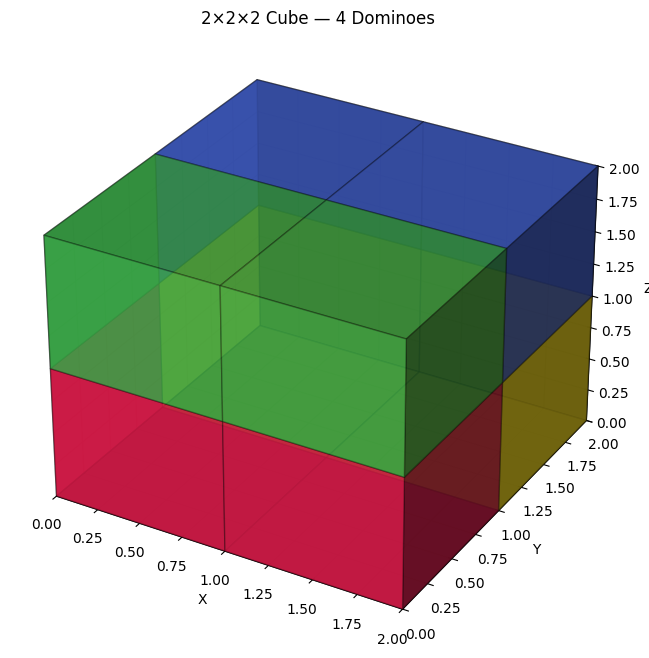

In [4]:
fig, ax = plot_solution(sol, 2, title="2×2×2 Cube — 4 Dominoes")
plt.show()

## 3. The Soma Cube

The classic Soma puzzle: 7 polycube pieces (one tricube + six tetracubes) that assemble
into a 3×3×3 cube. It has **240 unique solutions** (11,520 counting all rotations/reflections).

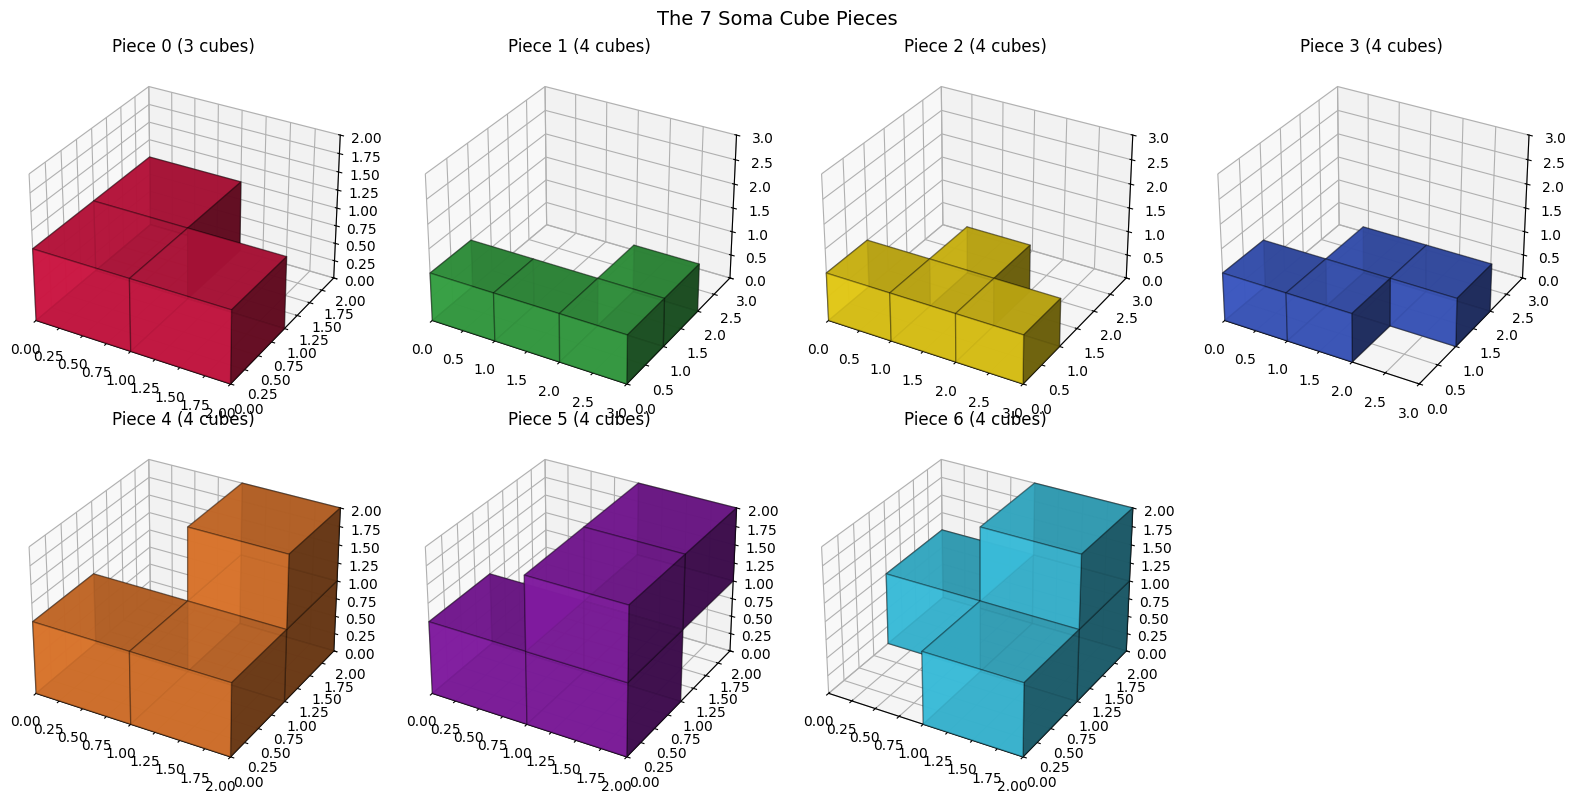

In [5]:
# Visualize the 7 Soma pieces
fig = plot_pieces(SOMA_PIECES, title="The 7 Soma Cube Pieces")
plt.show()

In [6]:
# Solve the Soma cube
soma_solutions = solve(SOMA_PIECES)

if soma_solutions:
    soma_sol = soma_solutions[0]
    print("\nSolution:")
    for pidx, cells in sorted(soma_sol.items()):
        print(f"  Piece {pidx}: {sorted(cells)}")
    assert verify_solution(soma_sol, 3), "Solution verification failed!"
    print("\nVerified: perfect 3×3×3 cube!")

Target: 3x3x3 cube (27 cells, 7 pieces)
  Piece 0: 3 cubes, 144 placements
  Piece 1: 4 cubes, 144 placements
  Piece 2: 4 cubes, 72 placements
  Piece 3: 4 cubes, 72 placements
  Piece 4: 4 cubes, 96 placements
  Piece 5: 4 cubes, 96 placements
  Piece 6: 4 cubes, 64 placements
  DLX matrix: 688 rows x 34 columns
Solving...
Found 1 solution(s).

Solution:
  Piece 0: [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(1), np.int64(0), np.int64(0)), (np.int64(1), np.int64(1), np.int64(0))]
  Piece 1: [(np.int64(1), np.int64(2), np.int64(0)), (np.int64(2), np.int64(0), np.int64(0)), (np.int64(2), np.int64(1), np.int64(0)), (np.int64(2), np.int64(2), np.int64(0))]
  Piece 2: [(np.int64(0), np.int64(2), np.int64(0)), (np.int64(0), np.int64(2), np.int64(1)), (np.int64(0), np.int64(2), np.int64(2)), (np.int64(1), np.int64(2), np.int64(1))]
  Piece 3: [(np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.in

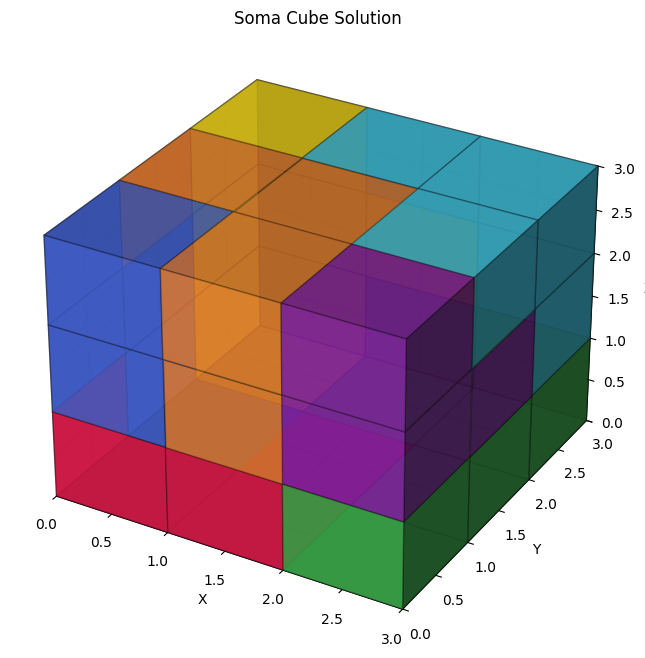

In [7]:
# Static visualization of the Soma solution
fig, ax = plot_solution(soma_sol, 3, title="Soma Cube Solution")
plt.show()

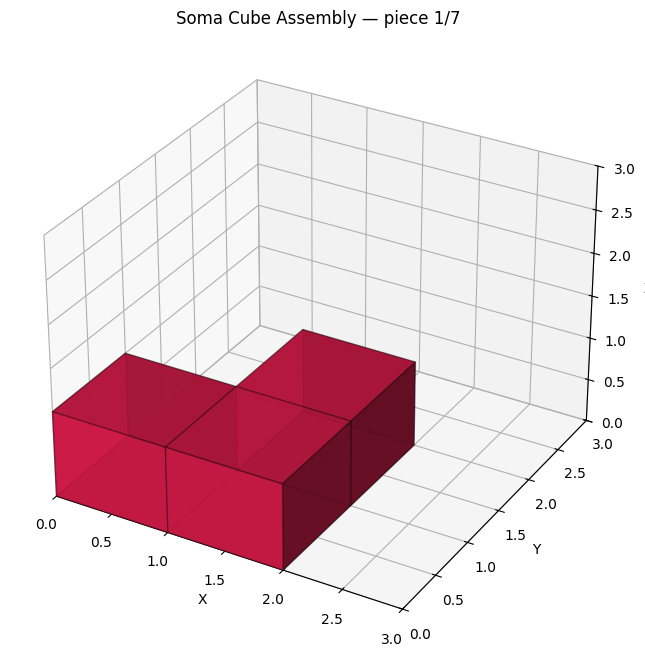

In [8]:
# Animated assembly — pieces placed one at a time
anim = animate_solution(soma_sol, 3, title="Soma Cube Assembly", interval=1000)
HTML(anim.to_jshtml())

## 4. Impossible Configuration

When the total volume isn't a perfect cube, the solver immediately rejects it.

In [9]:
# 3 dominoes = 6 cubes — not a perfect cube
impossible = solve([DOMINO] * 3)
print(f"Solutions found: {len(impossible)}")

Total volume 6 is not a perfect cube.
Solutions found: 0


## 5. Finding All Soma Solutions

The DLX solver can enumerate all solutions. The Soma cube has exactly **11,520 solutions**
(= 240 unique × 48 cube symmetries).

In [10]:
import time

t0 = time.time()
all_soma = solve(SOMA_PIECES, find_all=True)
elapsed = time.time() - t0

print(f"\nTotal solutions: {len(all_soma)}")
print(f"Unique (mod 48 symmetries): {len(all_soma) // 48}")
print(f"Time: {elapsed:.2f}s")

Target: 3x3x3 cube (27 cells, 7 pieces)
  Piece 0: 3 cubes, 144 placements
  Piece 1: 4 cubes, 144 placements
  Piece 2: 4 cubes, 72 placements
  Piece 3: 4 cubes, 72 placements
  Piece 4: 4 cubes, 96 placements
  Piece 5: 4 cubes, 96 placements
  Piece 6: 4 cubes, 64 placements
  DLX matrix: 688 rows x 34 columns
Solving...


Found 11520 solution(s).

Total solutions: 11520
Unique (mod 48 symmetries): 240
Time: 5.24s


Animation saved to soma_assembly.gif


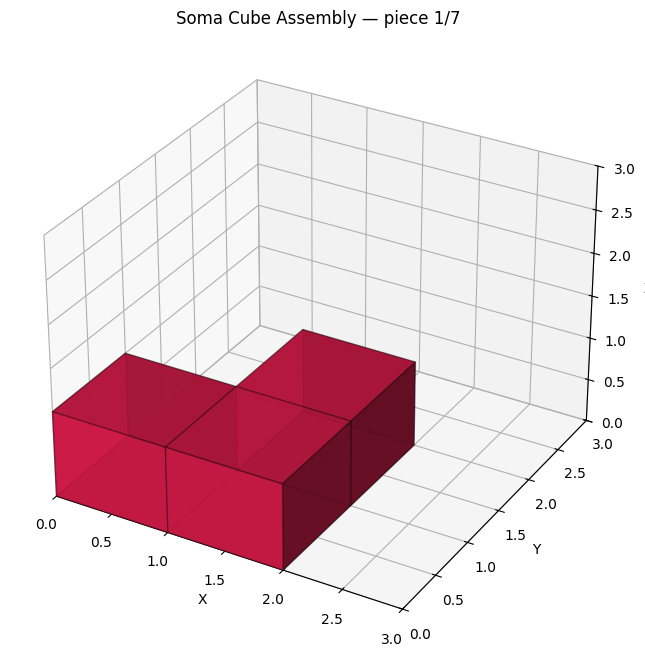

In [11]:
# Save the Soma animation as a GIF
anim = animate_solution(soma_sol, 3, title="Soma Cube Assembly",
                        interval=1000, save_path="soma_assembly.gif")